Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

Load Dataset

In [ ]:
loan = pd.read_csv("/content/Loan_default.csv")

Basic Data Exploration

In [ ]:
loan.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [ ]:
loan.shape

(43121, 18)

In [ ]:
loan.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43121 entries, 0 to 43120
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LoanID          43121 non-null  object 
 1   Age             43121 non-null  int64  
 2   Income          43121 non-null  int64  
 3   LoanAmount      43121 non-null  int64  
 4   CreditScore     43121 non-null  int64  
 5   MonthsEmployed  43121 non-null  int64  
 6   NumCreditLines  43121 non-null  int64  
 7   InterestRate    43121 non-null  float64
 8   LoanTerm        43121 non-null  int64  
 9   DTIRatio        43121 non-null  float64
 10  Education       43121 non-null  object 
 11  EmploymentType  43121 non-null  object 
 12  MaritalStatus   43121 non-null  object 
 13  HasMortgage     43120 non-null  object 
 14  HasDependents   43120 non-null  object 
 15  LoanPurpose     43120 non-null  object 
 16  HasCoSigner     43120 non-null  object 
 17  Default         43120 non-null 

In [ ]:
loan.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.000000,43121.00000,43120.000000
mean,43.525544,82507.635700,127580.621901,574.754273,59.569467,2.496440,13.521967,36.000835,0.50306,0.116605
std,14.973621,39019.086431,70846.173662,158.721387,34.614321,1.119296,6.638896,16.893544,0.23044,0.320953
min,18.000000,15000.000000,5005.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.10000,0.000000
25%,31.000000,48665.000000,66275.000000,437.000000,29.000000,1.000000,7.790000,24.000000,0.31000,0.000000
50%,43.000000,82571.000000,127577.000000,575.000000,60.000000,2.000000,13.560000,36.000000,0.51000,0.000000
75%,56.000000,116076.000000,189122.000000,712.000000,89.000000,3.000000,19.260000,48.000000,0.70000,0.000000
max,69.000000,149997.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.90000,1.000000


Check Missing Values

In [ ]:
loan.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
loan.dropna(inplace=True)

In [ ]:
loan.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


Check Duplicate Rows

In [ ]:
loan.duplicated().sum()

np.int64(0)

Drop Unnecessary Columns

In [ ]:
loan.drop("LoanID",axis=1,inplace=True)

Exploratory Data Analysis (EDA)

<Axes: xlabel='Income', ylabel='Count'>

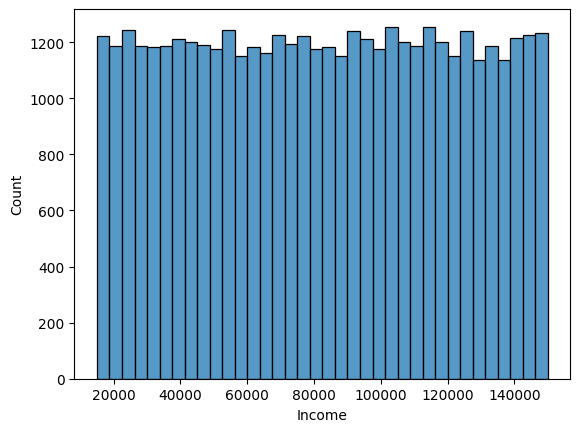

In [ ]:
sns.histplot(loan["Income"],kde=False)

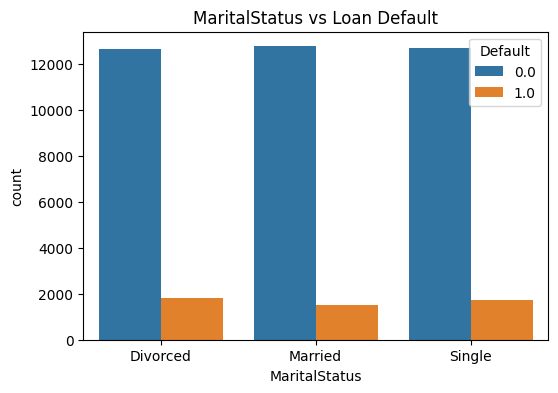

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='MaritalStatus',
              hue='Default',
              data=loan)

plt.title("MaritalStatus vs Loan Default")

plt.show()

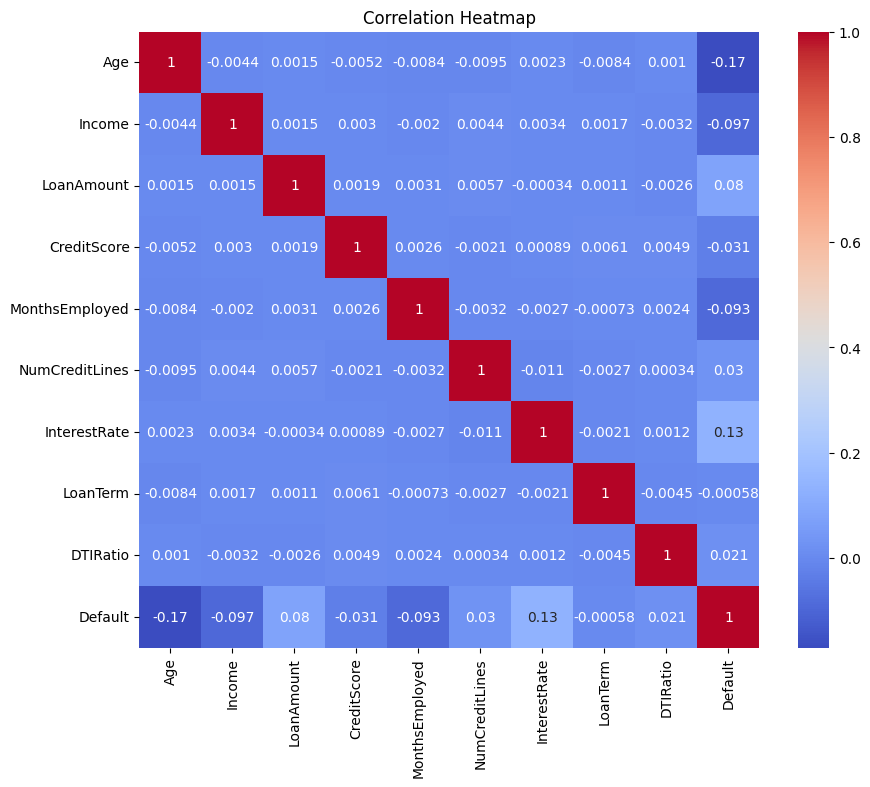

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(loan.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

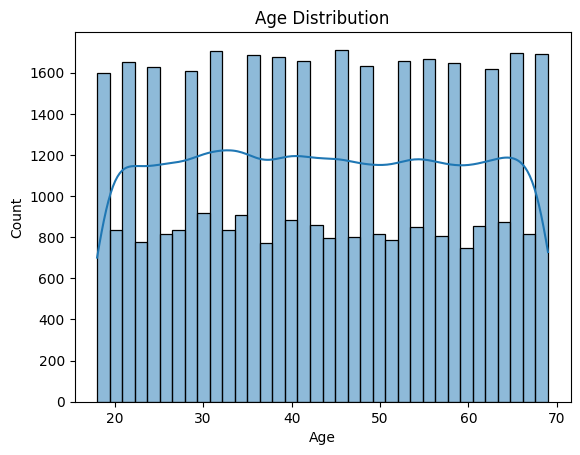

In [ ]:
sns.histplot(loan['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

Convert Text into Numbers

In [ ]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

columns_to_encode = ["HasMortgage","HasDependents","HasCoSigner"]

for col in columns_to_encode:
    loan[col] = le.fit_transform(loan[col])

In [ ]:
#One-Hot Encoding
loan = pd.get_dummies(loan, columns=['EmploymentType', 'MaritalStatus', 'LoanPurpose'], drop_first=True)

In [ ]:
loan["Education"].unique()

array(["Bachelor's", "Master's", 'High School', 'PhD'], dtype=object)

In [ ]:
education_mapping = {
    'High School': 1,
    "Bachelor's": 2,
    "Master's": 3,
    'PhD': 4
}

loan['Education'] = loan['Education'].map(education_mapping)

Feature Selection

In [ ]:
x=loan.drop("Default",axis=1)
y=loan["Default"]

In [ ]:
x

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,...,HasCoSigner,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,2,...,1,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,3,...,1,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,3,...,0,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,1,...,0,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,2,...,0,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43115,58,35633,32545,454,35,3,5.25,12,0.37,2,...,1,True,False,False,False,True,False,False,False,True
43116,67,109810,134490,747,55,2,21.50,12,0.26,3,...,0,False,True,False,False,True,False,False,True,False
43117,62,112152,199825,801,9,4,17.53,12,0.90,4,...,1,False,False,True,True,False,False,False,False,True
43118,22,130132,92134,790,34,4,16.51,24,0.22,2,...,0,False,False,True,False,False,False,True,False,False


In [ ]:
y

,Default
0,0.0
1,0.0
2,1.0
3,0.0
4,0.0
...,...
43115,0.0
43116,0.0
43117,0.0
43118,0.0


Target Variable Distribution & Train Test Split

<Axes: ylabel='count'>

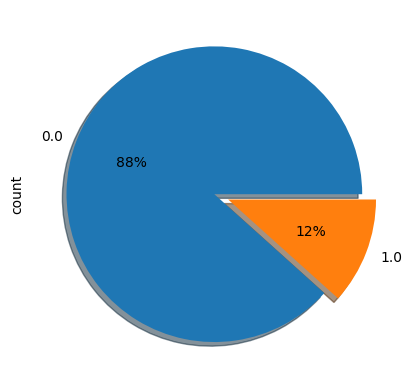

In [ ]:
loan.value_counts("Default").plot.pie(explode=(0,0.1),autopct="%.0f%%",shadow=True)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=45)

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

# check new class balance
print(y_train.value_counts())
print(y_train.value_counts()) # Corrected to print the resampled y_train

Default
0.0    30433
1.0    30433
Name: count, dtype: int64
Default
0.0    30433
1.0    30433
Name: count, dtype: int64


<Axes: ylabel='count'>

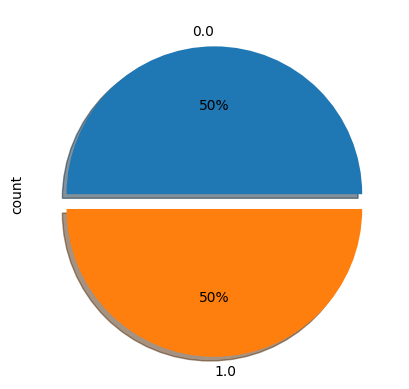

In [ ]:
y_train.value_counts().plot.pie(explode=(0,0.1),autopct="%.0f%%",shadow=True)

 Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train1=scaler.fit_transform(x_train)
x_train=pd.DataFrame(x_train1,columns=x.columns)

In [ ]:
x_test1=scaler.transform(x_test)
x_test=pd.DataFrame(x_test1,columns=x.columns)

Train Models

Logistic Regression

In [ ]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
pred= lr.predict(x_test)

Evaluation

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
accuracy= accuracy_score(y_test,pred)
accuracy

0.8091372912801484

In [ ]:
cm_result=confusion_matrix(y_test,pred)
cm_result

array([[6635, 1024],
       [ 622,  343]])

In [ ]:
report = classification_report(y_test,pred)
print("classication report:")
print(report)

classication report:
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89      7659
         1.0       0.25      0.36      0.29       965

    accuracy                           0.81      8624
   macro avg       0.58      0.61      0.59      8624
weighted avg       0.84      0.81      0.82      8624



In [ ]:
#gridsearchCV
param_grid = {
    'penalty':['l2'],
    'C':[0.001,0.01,0.1,1],
    'solver':['liblinear'],
    'max_iter':[100,200,300]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='accuracy',
    cv =5,
    verbose=1

)

In [ ]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1],
                         'max_iter': [100, 200, 300], 'penalty': ['l2'],
                         'solver': ['liblinear']},
             scoring='accuracy', verbose=1)

In [ ]:
# best parameter and score
print("best parameters;",grid_search.best_params_)
print("best accuracy;",grid_search.best_score_)

best parameters; {'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
best accuracy; 0.8434785953897139


In [ ]:
final_model = grid_search.best_estimator_

In [ ]:
final_model.fit(x_train,y_train)

LogisticRegression(C=0.01, solver='liblinear')

In [ ]:
#Prediction
y_pred = final_model.predict(x_test)

In [ ]:
y_pred

array([1., 0., 1., ..., 0., 0., 0.])

In [ ]:
accuracy1 = accuracy_score(y_test,y_pred)
accuracy1

0.8094851576994434

RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF =RandomForestClassifier(n_estimators=100,random_state=42)

In [ ]:
RF.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
pred = RF.predict(x_test)
accuracy_score = accuracy_score(y_test,pred)
accuracy_score

0.8560992578849722

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred
})

print(comparison.head(20))   # Show first 20 predictions

       Actual  Predicted
28705     0.0        0.0
5554      0.0        0.0
38097     0.0        0.0
26957     0.0        0.0
52        0.0        0.0
19884     0.0        0.0
6054      0.0        0.0
3903      0.0        0.0
35267     0.0        0.0
3640      0.0        0.0
11745     0.0        0.0
5157      0.0        0.0
19550     0.0        0.0
35726     0.0        1.0
34584     0.0        0.0
5437      0.0        1.0
17405     0.0        0.0
19670     0.0        0.0
17153     0.0        0.0
17731     0.0        0.0


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# model
rf = RandomForestClassifier(random_state=42)

# hyperparameter space
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}


In [ ]:
# random search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,          # number of random combinations to try
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
treee=DecisionTreeClassifier(criterion="gini",max_depth=5)
treee.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
from sklearn.metrics import accuracy_score
preed_x=treee.predict(x_test)
dt_accuracy_score=accuracy_score(y_test,preed_x)
dt_accuracy_score

0.6855287569573284

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=treee,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)


In [ ]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=5), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)